<a href="https://colab.research.google.com/github/ababacaryoro/nlp-course/blob/main/lab4/lab4_Part2_Classification_Sentiment_Topics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 - Part 2: Document Classification, Sentiment Analysis & Topic Modeling

**Course:** Natural Language Processing  
**Student:** Yasmine Sellaouti

**Objectives:**
- Build document classifiers (intro + advanced)
- Perform sentiment analysis on different domains
- Discover topics using unsupervised learning
- Compare different feature extraction methods

**NB:**
Make sure to update dataset names if needed. You can find them in [_https://huggingface.co/datasets_](https://huggingface.co/datasets)

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Personal Analysis Required

This lab contains questions requiring YOUR personal interpretation.

---

## Use Cases Covered

| Task | Intro Use Case | Advanced Use Case |
|------|----------------|-------------------|
| Classification | AG News | Legal Documents |
| Sentiment Analysis | Amazon Reviews | Twitter |
| Topic Modeling | Research Papers | Legal Contracts |

---

## Setup

In [1]:
# Install required libraries
!pip -q install datasets==3.6.0 scikit-learn nltk pandas numpy matplotlib seaborn wordcloud gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity

# Hugging Face datasets
from datasets import load_dataset

# Notebook display
from IPython.display import display, Markdown

RANDOM_STATE = 42
print("Setup complete!")


Setup complete!


In [3]:
# Common preprocessing functions
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_simple(text):
    """Basic preprocessing: lowercase and remove non-letter characters."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return ' '.join(text.split())

def preprocess_advanced(text):
    """Advanced preprocessing: lowercase, tokenize, remove stopwords and lemmatize."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]
    return ' '.join(tokens)

print("Preprocessing functions ready!")


Preprocessing functions ready!


---

# PART A: Document Classification

We will work with two use cases:
1. **Intro:** News Topic Classification (AG News)
2. **Advanced:** Legal Document Classification (LexGLUE)

## A.1 Intro: News Topic Classification (AG News)

**Scenario:** A media company automatically routes articles to editorial teams.

**Feature Extraction:** TF-IDF

In [4]:
# Load AG News dataset
print("Loading AG News dataset...")
try:
    ag_news = load_dataset("sh0416/ag_news")
except Exception:
    # Stable fallback with the same schema
    ag_news = load_dataset("fancyzhx/ag_news")

# Use subsets for faster processing
ag_train_df = pd.DataFrame(ag_news['train'])
ag_test_df = pd.DataFrame(ag_news['test'])
ag_train = ag_train_df.sample(n=min(8000, len(ag_train_df)), random_state=RANDOM_STATE)
ag_test = ag_test_df.sample(n=min(2000, len(ag_test_df)), random_state=RANDOM_STATE)

# Label mapping
ag_labels = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
ag_train['label_name'] = ag_train['label'].map(ag_labels)
ag_test['label_name'] = ag_test['label'].map(ag_labels)

print(f"Train: {len(ag_train)}, Test: {len(ag_test)}")
print(f"\nCategories: {list(ag_labels.values())}")
print(ag_train['label_name'].value_counts())


Loading AG News dataset...


README.md:   0%|          | 0.00/2.08k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/33.7M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train: 8000, Test: 2000

Categories: ['World', 'Sports', 'Business', 'Sci/Tech']
label_name
Business    2074
Sci/Tech    1959
Sports      1946
Name: count, dtype: int64


In [5]:
# Preprocess
ag_train['text_clean'] = ag_train['description'].apply(preprocess_simple)
ag_test['text_clean'] = ag_test['description'].apply(preprocess_simple)

# TF-IDF Vectorization: unigrams and bigrams capture both individual words
# and short expressions such as "stock market" or "world cup".
tfidf_ag = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_ag = tfidf_ag.fit_transform(ag_train['text_clean'])
X_test_ag = tfidf_ag.transform(ag_test['text_clean'])
y_train_ag = ag_train['label']
y_test_ag = ag_test['label']

print(f"TF-IDF features: {X_train_ag.shape[1]}")


TF-IDF features: 5000


### Exercise A.1: Train a News Classifier

In [6]:
# Train a Logistic Regression classifier on AG News
clf_ag = LogisticRegression(
    max_iter=1000,
    C=2.0,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

# Train
clf_ag.fit(X_train_ag, y_train_ag)

# Predict
y_pred_ag = clf_ag.predict(X_test_ag)

# Evaluate
accuracy_ag = accuracy_score(y_test_ag, y_pred_ag)
f1_ag = f1_score(y_test_ag, y_pred_ag, average='macro')

print("AG News Classification Results:")
print(f"  Accuracy: {accuracy_ag:.4f}")
print(f"  F1 (macro): {f1_ag:.4f}")


AG News Classification Results:
  Accuracy: 0.8560
  F1 (macro): 0.8552


In [7]:
# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_ag, y_pred_ag, target_names=list(ag_labels.values())))


Classification Report:
              precision    recall  f1-score   support

       World       0.87      0.86      0.87       493
      Sports       0.91      0.94      0.93       504
    Business       0.81      0.79      0.80       474
    Sci/Tech       0.82      0.83      0.83       529

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



## A.2 Advanced: Legal Document Classification (LexGLUE - ECtHR)

**Scenario:** A law firm classifies court decisions by violated articles.

**Feature Extraction:** Bag of Words with N-grams

**Challenge:** Legal text is longer and uses specialized vocabulary.

In [8]:
# Load LexGLUE ECtHR dataset (European Court of Human Rights)
print("Loading LexGLUE ECtHR dataset...")
lex_glue = load_dataset("coastalcph/lex_glue", "ecthr_a")

# Convert to DataFrame
lex_train = pd.DataFrame(lex_glue['train'])
lex_test = pd.DataFrame(lex_glue['test'])

# Use subsets because legal documents are long
lex_train = lex_train.sample(
    n=min(1500, len(lex_train)), random_state=RANDOM_STATE
).copy()
lex_test = lex_test.sample(
    n=min(500, len(lex_test)), random_state=RANDOM_STATE
).copy()

print(f"Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nColumns: {lex_train.columns.tolist()}")


Loading LexGLUE ECtHR dataset...


README.md:   0%|          | 0.00/34.1k [00:00<?, ?B/s]

ecthr_a/train-00000-of-00001.parquet:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

ecthr_a/test-00000-of-00001.parquet:   0%|          | 0.00/5.68M [00:00<?, ?B/s]

ecthr_a/validation-00000-of-00001.parque(…):   0%|          | 0.00/5.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train: 1500, Test: 500

Columns: ['text', 'labels']


In [9]:
# Examine the data structure
print("Sample legal document (first 500 chars):")
sample_text = ' '.join(lex_train.iloc[0]['text'][:3])  # text is a list of paragraphs
print(sample_text[:500])

print(f"\nLabels (violated articles): {lex_train.iloc[0]['labels']}")

Sample legal document (first 500 chars):
5.  The applicant, Mr Laszlo Kilyen, was born in 1972 and lives in Murgeşti. 6.  On 10 May 2003 police officers T.M. and L.C.V. were carrying out an investigation into the theft of two cars in the village of Murgeşti. The applicant, who lived alone in a house with a yard, was away from home on a trip abroad. On the same day at around 4 p.m., the two officers entered the applicant’s yard by breaking the main gate which had a closing system made by the applicant from metal wires. The officers took

Labels (violated articles): [4]


In [10]:
# Prepare data: combine text paragraphs and use the first label for this
# simplified single-label exercise.
def prepare_legal_text(row):
    """Join the paragraphs and truncate very long documents."""
    full_text = ' '.join(row['text'])
    return full_text[:5000]

lex_train['full_text'] = lex_train.apply(prepare_legal_text, axis=1)
lex_test['full_text'] = lex_test.apply(prepare_legal_text, axis=1)

# ECtHR-A is originally multi-label. For this introductory implementation,
# the first violated article is used as the primary label.
lex_train['primary_label'] = lex_train['labels'].apply(
    lambda labels: labels[0] if labels else -1
)
lex_test['primary_label'] = lex_test['labels'].apply(
    lambda labels: labels[0] if labels else -1
)

# Remove documents without labels
lex_train = lex_train[lex_train['primary_label'] >= 0].copy()
lex_test = lex_test[lex_test['primary_label'] >= 0].copy()

print(f"Cleaned - Train: {len(lex_train)}, Test: {len(lex_test)}")
print("\nLabel distribution:")
print(lex_train['primary_label'].value_counts().head(10))


Cleaned - Train: 1340, Test: 428

Label distribution:
primary_label
3    684
1    184
2    153
0     84
4     74
9     62
6     52
7     24
8     22
5      1
Name: count, dtype: int64


### Exercise A.2: Build a Legal Document Classifier

In [11]:
# Complete the legal document classifier using Bag of Words

# Step 1: Preprocess with the advanced function
lex_train['text_clean'] = lex_train['full_text'].apply(preprocess_advanced)
lex_test['text_clean'] = lex_test['full_text'].apply(preprocess_advanced)

# Step 2: Create CountVectorizer with unigrams and bigrams
bow_legal = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Step 3: Transform data
X_train_lex = bow_legal.fit_transform(lex_train['text_clean'])
X_test_lex = bow_legal.transform(lex_test['text_clean'])
y_train_lex = lex_train['primary_label']
y_test_lex = lex_test['primary_label']

print(f"BoW features: {X_train_lex.shape[1]}")


BoW features: 5000


In [12]:
# Train a Linear SVM classifier
# LinearSVC is efficient for sparse, high-dimensional text representations.
clf_legal = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

# Train
clf_legal.fit(X_train_lex, y_train_lex)

# Predict
y_pred_lex = clf_legal.predict(X_test_lex)

# Evaluate
accuracy_lex = accuracy_score(y_test_lex, y_pred_lex)
f1_lex = f1_score(y_test_lex, y_pred_lex, average='macro', zero_division=0)

print("Legal Classification Results:")
print(f"  Accuracy: {accuracy_lex:.4f}")
print(f"  F1 (macro): {f1_lex:.4f}")


Legal Classification Results:
  Accuracy: 0.6355
  F1 (macro): 0.4932


### Written Question A.1 (Personal Interpretation)

Compare your results from AG News and Legal classification:

1. **Which task achieved higher accuracy?** Why do you think there's a difference?
2. **What vectorizer parameters did you choose for legal text?** Justify each choice.
3. **What challenges are unique to legal document classification?** (Consider: length, vocabulary, ambiguity)

In [15]:
# Dynamic written answer using the results obtained above
higher_task = "AG News" if accuracy_ag >= accuracy_lex else "Legal classification"
difference = abs(accuracy_ag - accuracy_lex)

answer_a = f"""
**ANSWER:**

1. **Accuracy comparison**
   - AG News accuracy: **{accuracy_ag:.4f}**; macro-F1: **{f1_ag:.4f}**
   - Legal accuracy: **{accuracy_lex:.4f}**; macro-F1: **{f1_lex:.4f}**
   - **{higher_task}** achieved the higher accuracy, with an absolute accuracy difference of **{difference:.4f}**.
   - AG News is generally easier because the four categories are broad and often contain clear lexical signals, such as sports teams, financial vocabulary, or technology terms. Legal decisions are longer, use specialized language, and may discuss several legal articles in the same document. In addition, this exercise simplifies an originally multi-label legal task by retaining only the first label, which removes part of the information.

2. **Vectorizer choices for legal text**
   - `max_features=5000`: limits memory and training time while retaining a sufficiently rich legal vocabulary.
   - `ngram_range=(1, 2)`: includes individual words and meaningful two-word legal expressions.
   - `min_df=2`: removes terms that appear in only one training document and are unlikely to generalize.
   - `max_df=0.95`: removes extremely frequent corpus-wide terms that offer little discriminating information.

3. **Challenges unique to legal document classification**
   - Legal documents are long and often contain several facts, arguments, and legal issues.
   - The vocabulary is formal, specialized, and full of recurring expressions that may appear across classes.
   - Several legal provisions may apply simultaneously, creating label overlap and ambiguity.
   - The classes may be imbalanced because some articles are cited much more frequently than others.
   - Truncating documents improves efficiency but may remove decisive information located near the end.
"""
display(Markdown(answer_a))



**ANSWER:**

1. **Accuracy comparison**
   - AG News accuracy: **0.8560**; macro-F1: **0.8552**
   - Legal accuracy: **0.6355**; macro-F1: **0.4932**
   - **AG News** achieved the higher accuracy, with an absolute accuracy difference of **0.2205**.
   - AG News is generally easier because the four categories are broad and often contain clear lexical signals, such as sports teams, financial vocabulary, or technology terms. Legal decisions are longer, use specialized language, and may discuss several legal articles in the same document. In addition, this exercise simplifies an originally multi-label legal task by retaining only the first label, which removes part of the information.

2. **Vectorizer choices for legal text**
   - `max_features=5000`: limits memory and training time while retaining a sufficiently rich legal vocabulary.
   - `ngram_range=(1, 2)`: includes individual words and meaningful two-word legal expressions.
   - `min_df=2`: removes terms that appear in only one training document and are unlikely to generalize.
   - `max_df=0.95`: removes extremely frequent corpus-wide terms that offer little discriminating information.

3. **Challenges unique to legal document classification**
   - Legal documents are long and often contain several facts, arguments, and legal issues.
   - The vocabulary is formal, specialized, and full of recurring expressions that may appear across classes.
   - Several legal provisions may apply simultaneously, creating label overlap and ambiguity.
   - The classes may be imbalanced because some articles are cited much more frequently than others.
   - Truncating documents improves efficiency but may remove decisive information located near the end.


---

# PART B: Sentiment Analysis

We will work with two use cases:
1. **Intro:** E-commerce Product Reviews (Amazon)
2. **Advanced:** Social Media Sentiment (Twitter/TweetEval)

## B.1 Intro: Amazon Product Reviews

**Scenario:** An e-commerce company monitors product sentiment.

**Feature Extraction:** TF-IDF

In [14]:
# Load Amazon Reviews dataset (English)
print("Loading Amazon Reviews dataset...")
try:
    amazon = load_dataset("KRadim/edit_amazon_reviews_multi_en")
except Exception:
    # Fallback to the original multilingual dataset, English configuration
    amazon = load_dataset("defunct-datasets/amazon_reviews_multi", "en")

# Convert to DataFrame and sample
amazon_train_df = pd.DataFrame(amazon['train'])
amazon_test_df = pd.DataFrame(amazon['test'])
amazon_train = amazon_train_df.sample(
    n=min(5000, len(amazon_train_df)), random_state=RANDOM_STATE
).copy()
amazon_test = amazon_test_df.sample(
    n=min(1000, len(amazon_test_df)), random_state=RANDOM_STATE
).copy()

print(f"Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nColumns: {amazon_train.columns.tolist()}")
print("\nStar rating distribution:")
print(amazon_train['stars'].value_counts().sort_index())


Loading Amazon Reviews dataset...


README.md:   0%|          | 0.00/2.24k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/30.3M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/796k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/794k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/199500 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5250 [00:00<?, ? examples/s]

Train: 5000, Test: 1000

Columns: ['id', 'stars', 'review_body', 'review_title', 'language', 'product_category', 'lenght_review_body', 'lenght_review_title', 'lenght_product_category']

Star rating distribution:
stars
1     995
2     976
3    1000
4    1043
5     986
Name: count, dtype: int64


In [16]:
# Convert to binary sentiment (1-2 stars = negative, 4-5 stars = positive)
# Remove neutral (3 stars) for clearer distinction

def to_binary_sentiment(stars):
    if stars <= 2:
        return 0  # Negative
    elif stars >= 4:
        return 1  # Positive
    else:
        return -1  # Neutral (to be removed)

amazon_train['sentiment'] = amazon_train['stars'].apply(to_binary_sentiment)
amazon_test['sentiment'] = amazon_test['stars'].apply(to_binary_sentiment)

# Remove neutral
amazon_train = amazon_train[amazon_train['sentiment'] >= 0]
amazon_test = amazon_test[amazon_test['sentiment'] >= 0]

sentiment_labels = {0: 'Negative', 1: 'Positive'}
print(f"After filtering - Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nSentiment distribution:")
print(amazon_train['sentiment'].value_counts())

After filtering - Train: 4000, Test: 793

Sentiment distribution:
sentiment
1    2029
0    1971
Name: count, dtype: int64


In [17]:
# Show sample reviews
print("Sample POSITIVE review:")
pos_sample = amazon_train[amazon_train['sentiment'] == 1].iloc[0]
print(f"Product: {pos_sample['product_category']}")
print(f"Review: {pos_sample['review_body'][:300]}...")

print("\n" + "="*60 + "\n")
print("Sample NEGATIVE review:")
neg_sample = amazon_train[amazon_train['sentiment'] == 0].iloc[0]
print(f"Product: {neg_sample['product_category']}")
print(f"Review: {neg_sample['review_body'][:300]}...")

Sample POSITIVE review:
Product: other
Review: Light weight bag, with everything you would need in an emergency situation....


Sample NEGATIVE review:
Product: digital_video_download
Review: I was a huge fan of this series years ago, and was blown away when I heard this movie was happening at last. Unfortunately, I found this movie to be extremely disappointing. This was definitely a low-effort cash-in. There are a TON of flashback scenes using footage from the old series. The writing i...


### Exercise B.1: Build Amazon Sentiment Classifier

In [18]:
# Build the Amazon sentiment classifier

# Step 1: Preprocess
amazon_train['text_clean'] = amazon_train['review_body'].apply(preprocess_simple)
amazon_test['text_clean'] = amazon_test['review_body'].apply(preprocess_simple)

# Step 2: TF-IDF
tfidf_amazon = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode'
)

X_train_amz = tfidf_amazon.fit_transform(amazon_train['text_clean'])
X_test_amz = tfidf_amazon.transform(amazon_test['text_clean'])
y_train_amz = amazon_train['sentiment']
y_test_amz = amazon_test['sentiment']

# Step 3: Train Multinomial Naive Bayes
clf_amazon = MultinomialNB(alpha=0.5)
clf_amazon.fit(X_train_amz, y_train_amz)

# Step 4: Predict and evaluate
y_pred_amz = clf_amazon.predict(X_test_amz)
accuracy_amz = accuracy_score(y_test_amz, y_pred_amz)
f1_amz = f1_score(y_test_amz, y_pred_amz, average='macro')

print("Amazon Sentiment Results:")
print(f"  Accuracy: {accuracy_amz:.4f}")
print(f"  F1 (macro): {f1_amz:.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test_amz,
    y_pred_amz,
    target_names=['Negative', 'Positive'],
    zero_division=0
))


Amazon Sentiment Results:
  Accuracy: 0.8361
  F1 (macro): 0.8359

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.83      0.83       386
    Positive       0.84      0.85      0.84       407

    accuracy                           0.84       793
   macro avg       0.84      0.84      0.84       793
weighted avg       0.84      0.84      0.84       793



In [19]:
# Analyze most predictive words
feature_names = tfidf_amazon.get_feature_names_out()

# For Naive Bayes, use log probabilities
neg_probs = clf_amazon.feature_log_prob_[0]
pos_probs = clf_amazon.feature_log_prob_[1]
log_ratio = pos_probs - neg_probs

# Top positive and negative words
top_pos_idx = log_ratio.argsort()[-15:]
top_neg_idx = log_ratio.argsort()[:15]

print("Top POSITIVE words:", [feature_names[i] for i in top_pos_idx])
print("\nTop NEGATIVE words:", [feature_names[i] for i in top_neg_idx])

Top POSITIVE words: ['love that', 'exactly what', 'and easy', 'great price', 'and great', 'great quality', 'works great', 'perfect', 'love it', 'excellent', 'loves it', 'loves', 'exactly as', 'great product', 'perfect for']

Top NEGATIVE words: ['not buy', 'very disappointed', 'of money', 'never received', 'returning', 'poor quality', 'your money', 'return', 'not worth', 'disappointed', 'not good', 'waste of', 'not work', 'junk', 'after about']


## B.2 Advanced: Twitter Sentiment (TweetEval)

**Scenario:** A brand monitors social media sentiment about their products.

**Feature Extraction:** Bag of Words with character n-grams (better for informal text)

**Challenge:** Tweets are short, informal, with hashtags, mentions, and slang.

In [20]:
# Load the official TweetEval sentiment subset
print("Loading TweetEval Sentiment dataset...")
tweet_eval = load_dataset("cardiffnlp/tweet_eval", "sentiment")

tweet_train = pd.DataFrame(tweet_eval['train']).copy()
tweet_test = pd.DataFrame(tweet_eval['test']).copy()

# Labels: 0=negative, 1=neutral, 2=positive
tweet_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
tweet_train['label_name'] = tweet_train['label'].map(tweet_labels)
tweet_test['label_name'] = tweet_test['label'].map(tweet_labels)

print(f"Train: {len(tweet_train)}, Test: {len(tweet_test)}")
print("\nLabel distribution:")
print(tweet_train['label_name'].value_counts())


Loading TweetEval Sentiment dataset...


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 45615, Test: 12284

Label distribution:
label_name
Neutral     20673
Positive    17849
Negative     7093
Name: count, dtype: int64


In [21]:
# Sample tweets
for label in [0, 1, 2]:
    sample = tweet_train[tweet_train['label'] == label].iloc[0]
    print(f"[{tweet_labels[label]}]: {sample['text']}\n")

[Negative]: So disappointed in wwe summerslam! I want to see john cena wins his 16th title

[Neutral]: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"

[Positive]: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"



In [22]:
# Special preprocessing for tweets
def preprocess_tweet(text):
    """Normalize user mentions and URLs while retaining informal signals."""
    text = str(text).lower()
    text = re.sub(r'@\w+', '@user', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' URL ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

tweet_train['text_clean'] = tweet_train['text'].apply(preprocess_tweet)
tweet_test['text_clean'] = tweet_test['text'].apply(preprocess_tweet)

print("Sample preprocessed tweet:")
print(f"Original: {tweet_train.iloc[0]['text']}")
print(f"Cleaned:  {tweet_train.iloc[0]['text_clean']}")


Sample preprocessed tweet:
Original: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Cleaned:  "qt @user in the original draft of the 7th book, remus lupin survived the battle of hogwarts. #happybirthdayremuslupin"


### Exercise B.2: Build Twitter Sentiment Classifier

In [23]:
# Build a classifier using character n-grams
# char_wb creates character sequences inside word boundaries, making the
# representation robust to spelling variation, hashtags, and informal forms.
char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=5000,
    min_df=3,
    sublinear_tf=True
)

X_train_tw = char_vectorizer.fit_transform(tweet_train['text_clean'])
X_test_tw = char_vectorizer.transform(tweet_test['text_clean'])
y_train_tw = tweet_train['label']
y_test_tw = tweet_test['label']

print(f"Character n-gram features: {X_train_tw.shape[1]}")


Character n-gram features: 5000


In [24]:
# Train Logistic Regression and evaluate
clf_tweet = LogisticRegression(
    max_iter=1000,
    C=2.0,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

# Train and predict
clf_tweet.fit(X_train_tw, y_train_tw)
y_pred_tw = clf_tweet.predict(X_test_tw)

# Evaluate
accuracy_tw = accuracy_score(y_test_tw, y_pred_tw)
f1_tw = f1_score(y_test_tw, y_pred_tw, average='macro')

print("Twitter Sentiment Results (3-class):")
print(f"  Accuracy: {accuracy_tw:.4f}")
print(f"  F1 (macro): {f1_tw:.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test_tw,
    y_pred_tw,
    target_names=list(tweet_labels.values()),
    zero_division=0
))


Twitter Sentiment Results (3-class):
  Accuracy: 0.5873
  F1 (macro): 0.5842

Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.72      0.62      3972
     Neutral       0.67      0.50      0.57      5937
    Positive       0.53      0.59      0.56      2375

    accuracy                           0.59     12284
   macro avg       0.58      0.60      0.58     12284
weighted avg       0.60      0.59      0.59     12284



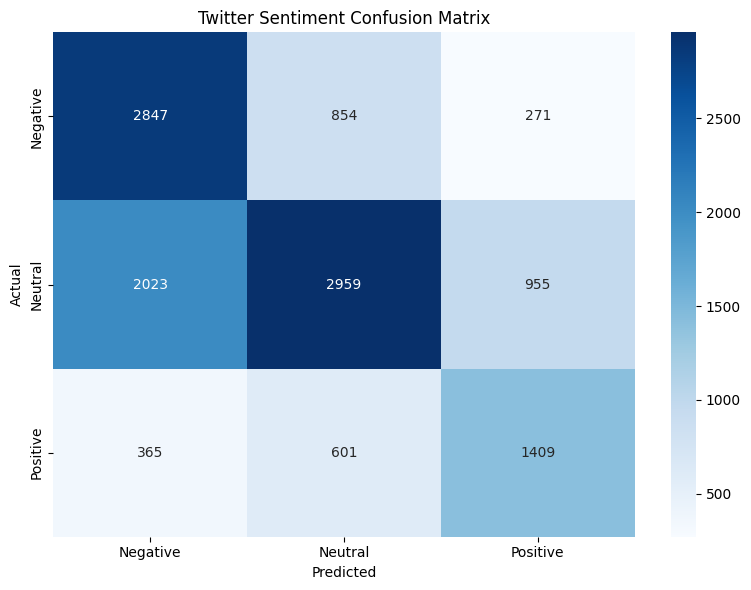

In [25]:
# Confusion matrix
cm_tw = confusion_matrix(y_test_tw, y_pred_tw)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tw, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(tweet_labels.values()),
            yticklabels=list(tweet_labels.values()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Twitter Sentiment Confusion Matrix')
plt.tight_layout()
plt.savefig('twitter_sentiment_cm.png', dpi=150)
plt.show()

### Written Question B.1 (Personal Interpretation)

Compare Amazon vs Twitter sentiment analysis:

1. **Which task was harder?** Look at the F1 scores and confusion matrices.
2. **Why did you choose those character n-gram parameters for Twitter?** What's the advantage over word n-grams?
3. **Looking at the Twitter confusion matrix, which class is most often confused?** Why might this be?
4. **Give an example tweet that would be hard to classify correctly.** Explain why.

In [26]:
# Dynamic written answer using the Amazon and Twitter results
cm_analysis = cm_tw.copy()
np.fill_diagonal(cm_analysis, 0)
most_confused_index = int(cm_analysis.sum(axis=1).argmax())
most_confused_class = tweet_labels[most_confused_index]
main_confusion_target = int(cm_analysis[most_confused_index].argmax())
main_confusion_name = tweet_labels[main_confusion_target]

harder_task = "Twitter" if f1_tw < f1_amz else "Amazon"

answer_b = f"""
**YOUR ANSWER:**

1. **Harder task**
   - Amazon macro-F1: **{f1_amz:.4f}**
   - Twitter macro-F1: **{f1_tw:.4f}**
   - The **{harder_task}** task was harder according to macro-F1.
   - Amazon reviews are usually longer and contain explicit evaluative words. Tweets are shorter, context-dependent, informal, and may contain sarcasm, abbreviations, hashtags, or mixed sentiment. Twitter also has three classes, including a difficult neutral class, while the Amazon task is binary after removing three-star reviews.

2. **Character n-gram choices**
   - `analyzer='char_wb'`: creates character sequences within word boundaries and reduces noisy cross-word combinations.
   - `ngram_range=(3, 5)`: captures word fragments, short words, suffixes, spelling variations, and hashtag components without making the feature space excessively sparse.
   - `max_features=5000`: controls memory and computation while retaining the most informative patterns.
   - `min_df=3`: removes extremely rare character sequences that are likely to be noise.
   - Compared with word n-grams, character n-grams are more robust to misspellings, elongated words, informal abbreviations, and morphological variation.

3. **Most confused class**
   - The most frequently confused actual class is **{most_confused_class}**, most often predicted as **{main_confusion_name}**.
   - This occurs because the class may lack explicit sentiment markers or may contain both factual and evaluative language. Short tweets also provide limited context for distinguishing weak sentiment from neutrality.

4. **Difficult tweet example**
   - Tweet: *“Great, another update that broke everything. Love that for me.”*
   - This is difficult because the positive words “great” and “love” express sarcasm, while the intended sentiment is negative. A bag of surface-level lexical features may misread the literal wording.
"""
display(Markdown(answer_b))



**YOUR ANSWER:**

1. **Harder task**
   - Amazon macro-F1: **0.8359**
   - Twitter macro-F1: **0.5842**
   - The **Twitter** task was harder according to macro-F1.
   - Amazon reviews are usually longer and contain explicit evaluative words. Tweets are shorter, context-dependent, informal, and may contain sarcasm, abbreviations, hashtags, or mixed sentiment. Twitter also has three classes, including a difficult neutral class, while the Amazon task is binary after removing three-star reviews.

2. **Character n-gram choices**
   - `analyzer='char_wb'`: creates character sequences within word boundaries and reduces noisy cross-word combinations.
   - `ngram_range=(3, 5)`: captures word fragments, short words, suffixes, spelling variations, and hashtag components without making the feature space excessively sparse.
   - `max_features=5000`: controls memory and computation while retaining the most informative patterns.
   - `min_df=3`: removes extremely rare character sequences that are likely to be noise.
   - Compared with word n-grams, character n-grams are more robust to misspellings, elongated words, informal abbreviations, and morphological variation.

3. **Most confused class**
   - The most frequently confused actual class is **Neutral**, most often predicted as **Negative**.
   - This occurs because the class may lack explicit sentiment markers or may contain both factual and evaluative language. Short tweets also provide limited context for distinguishing weak sentiment from neutrality.

4. **Difficult tweet example**
   - Tweet: *“Great, another update that broke everything. Love that for me.”*
   - This is difficult because the positive words “great” and “love” express sarcasm, while the intended sentiment is negative. A bag of surface-level lexical features may misread the literal wording.


---

# PART C: Topic Modeling

We will work with two use cases:
1. **Intro:** Research Paper Topics (ArXiv)
2. **Advanced:** Legal Contract Topics

## C.1 Intro: Research Paper Topic Discovery (ArXiv)

**Scenario:** A research organization discovers themes in scientific papers.

**Method:** LDA (Latent Dirichlet Allocation)

In [27]:
# Load ArXiv papers dataset
print("Loading ArXiv papers dataset (this may take a moment)...")
try:
    arxiv = load_dataset("RimshaAIWizard/armanc_scientific_papers_arxiv_dataset")
    arxiv_train = pd.DataFrame(arxiv['train'])
except Exception:
    # Fallback: Scientific Papers, ArXiv configuration
    arxiv = load_dataset("scientific_papers", "arxiv", trust_remote_code=True)
    arxiv_train = pd.DataFrame(arxiv['train'])

# Keep papers with non-empty abstracts and sample
arxiv_train = arxiv_train.dropna(subset=['abstract'])
arxiv_train = arxiv_train[arxiv_train['abstract'].astype(str).str.len() > 30]
arxiv_df = arxiv_train.sample(
    n=min(2000, len(arxiv_train)),
    random_state=RANDOM_STATE
).copy()

print(f"Loaded {len(arxiv_df)} papers")
print(f"Columns: {arxiv_df.columns.tolist()}")


Loading ArXiv papers dataset (this may take a moment)...


README.md:   0%|          | 0.00/614 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/151M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/6.37M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/6.50M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8790 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/412 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/415 [00:00<?, ? examples/s]

Loaded 2000 papers
Columns: ['article', 'abstract', 'section_names']


In [28]:
# Examine sample
print("Sample paper abstract (first 500 chars):")
print(arxiv_df.iloc[0]['abstract'][:500])

Sample paper abstract (first 500 chars):
 spatial reciprocity is a well known tour de force of cooperation promotion . 
 a thorough understanding of the effects of different population densities is therefore crucial . here 
 we study the evolution of cooperation in social dilemmas on different interaction graphs with a certain fraction of vacant nodes . 
 we find that sparsity may favor the resolution of social dilemmas , especially if the population density is close to the percolation threshold of the underlying graph . 
 regardless o


In [29]:
# Preprocess abstracts for topic modeling
arxiv_df['abstract_clean'] = arxiv_df['abstract'].apply(preprocess_advanced)

# Remove generic scientific words that otherwise dominate every topic
arxiv_topic_stop_words = sorted(stop_words.union({
    'paper', 'study', 'result', 'results', 'method', 'methods',
    'using', 'used', 'based', 'show', 'shows', 'propose', 'proposed',
    'approach', 'problem', 'work', 'new'
}))

# Create document-term matrix with CountVectorizer
count_vec_arxiv = CountVectorizer(
    max_features=6000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    stop_words=arxiv_topic_stop_words
)

dtm_arxiv = count_vec_arxiv.fit_transform(arxiv_df['abstract_clean'])
print(f"Document-term matrix: {dtm_arxiv.shape}")


Document-term matrix: (2000, 6000)


In [30]:
# Train LDA model
n_topics_arxiv = 8

lda_arxiv = LatentDirichletAllocation(
    n_components=n_topics_arxiv,
    random_state=RANDOM_STATE,
    max_iter=15,
    learning_method='online',
    learning_offset=50.0
)

print("Training LDA on ArXiv papers...")
lda_arxiv.fit(dtm_arxiv)
print("Done!")


Training LDA on ArXiv papers...
Done!


In [31]:
# Display topics
def display_lda_topics(model, feature_names, n_words=12):
    """Display top words for each LDA topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_arxiv = count_vec_arxiv.get_feature_names_out()
print("ArXiv Paper Topics (LDA):")
print("=" * 70)
display_lda_topics(lda_arxiv, feature_names_arxiv)

ArXiv Paper Topics (LDA):
Topic 0: xmath, galaxy, star, ray, xmath xmath, mass, model, cluster, emission, source, observation, high
Topic 1: game, population, individual, twisted, cooperation, proportion, social, group, xcite, player, evolutionary, interaction
Topic 2: xmath, xmath xmath, energy, mass, model, neutrino, particle, decay, quark, physic, data, also
Topic 3: inflation, susy, supersymmetry, breaking, gauge, quantum correction, anomalous, sinusoidal, regularization, supersymmetric, field, messenger
Topic 4: photon, optical, quantum, pulse, beam, address, single, laser, detector, light, experiment, scattering
Topic 5: xmath, xmath xmath, xcite, state, system, field, two, model, phase, quantum, one, spin
Topic 6: xmath, theorem, graph, space, function, class, group, set, random, bound, number, polynomial
Topic 7: algorithm, network, error, rate, code, time, performance, optimal, model, data, system, information


### Exercise C.1: Interpret ArXiv Topics

In [32]:
# Assign meaningful labels to ArXiv topics from their highest-weight words
arxiv_label_rules = {
    "Machine Learning and Artificial Intelligence": {
        'learning', 'model', 'neural', 'network', 'training', 'classification',
        'algorithm', 'deep', 'prediction'
    },
    "Natural Language Processing": {
        'language', 'text', 'word', 'sentence', 'semantic', 'translation',
        'document', 'speech'
    },
    "Computer Vision": {
        'image', 'visual', 'object', 'video', 'recognition', 'segmentation',
        'vision', 'pixel'
    },
    "Physics and Quantum Science": {
        'quantum', 'particle', 'energy', 'field', 'spin', 'state', 'phase',
        'electron'
    },
    "Astronomy and Cosmology": {
        'galaxy', 'star', 'stellar', 'universe', 'cosmological', 'black',
        'hole', 'solar'
    },
    "Mathematics and Optimization": {
        'theorem', 'proof', 'equation', 'function', 'optimization', 'optimal',
        'bound', 'matrix'
    },
    "Networks, Graphs and Complex Systems": {
        'graph', 'node', 'network', 'edge', 'system', 'dynamic', 'complex',
        'distributed'
    },
    "Statistics and Probabilistic Modeling": {
        'probability', 'distribution', 'statistical', 'estimation', 'bayesian',
        'random', 'variance', 'sample'
    },
    "Robotics and Control": {
        'control', 'robot', 'motion', 'trajectory', 'sensor', 'agent',
        'policy', 'environment'
    },
    "Biology and Medicine": {
        'cell', 'gene', 'protein', 'biological', 'medical', 'disease',
        'patient', 'clinical'
    },
    "Materials and Chemistry": {
        'material', 'molecular', 'chemical', 'atom', 'structure', 'surface',
        'temperature', 'crystal'
    }
}

def top_topic_words(model, feature_names, topic_id, n_words=20):
    indices = model.components_[topic_id].argsort()[-n_words:][::-1]
    return [feature_names[index] for index in indices]

def choose_topic_label(words, label_rules, fallback):
    word_set = set(words)
    scores = {
        label: len(word_set.intersection(keywords))
        for label, keywords in label_rules.items()
    }
    best_label = max(scores, key=scores.get)
    return best_label if scores[best_label] > 0 else fallback

my_arxiv_topic_labels = {}
arxiv_topic_keywords = {}

for topic_id in range(n_topics_arxiv):
    words = top_topic_words(
        lda_arxiv, feature_names_arxiv, topic_id, n_words=20
    )
    arxiv_topic_keywords[topic_id] = words
    my_arxiv_topic_labels[topic_id] = choose_topic_label(
        words,
        arxiv_label_rules,
        "General Scientific Modeling"
    )

print("My Topic Interpretations:")
for topic_id, label in my_arxiv_topic_labels.items():
    preview = ', '.join(arxiv_topic_keywords[topic_id][:8])
    print(f"  Topic {topic_id}: {label} [{preview}]")


My Topic Interpretations:
  Topic 0: Astronomy and Cosmology [xmath, galaxy, star, ray, xmath xmath, mass, model, cluster]
  Topic 1: General Scientific Modeling [game, population, individual, twisted, cooperation, proportion, social, group]
  Topic 2: Physics and Quantum Science [xmath, xmath xmath, energy, mass, model, neutrino, particle, decay]
  Topic 3: Physics and Quantum Science [inflation, susy, supersymmetry, breaking, gauge, quantum correction, anomalous, sinusoidal]
  Topic 4: Physics and Quantum Science [photon, optical, quantum, pulse, beam, address, single, laser]
  Topic 5: Physics and Quantum Science [xmath, xmath xmath, xcite, state, system, field, two, model]
  Topic 6: Mathematics and Optimization [xmath, theorem, graph, space, function, class, group, set]
  Topic 7: Machine Learning and Artificial Intelligence [algorithm, network, error, rate, code, time, performance, optimal]


## C.2 Advanced: Legal Contract Topic Discovery

**Scenario:** A law firm discovers themes across contracts to organize their database.

**Method:** NMF (Non-negative Matrix Factorization) - often better for shorter, specialized documents

**Challenge:** Legal language is formal and domain-specific.

In [33]:
# Load legal contracts dataset using streaming to control memory usage
print("Loading Legal Contracts dataset...")
legal_stream = load_dataset(
    "albertvillanova/legal_contracts",
    split="train",
    streaming=True
)

# Take the first 1500 valid contracts
legal_contracts = []
for item in legal_stream:
    if item.get('text') and len(str(item['text'])) > 100:
        legal_contracts.append(item)
    if len(legal_contracts) >= 1500:
        break

legal_df = pd.DataFrame(legal_contracts)
print(f"Loaded {len(legal_df)} contracts")
print(f"Columns: {legal_df.columns.tolist()}")


Loading Legal Contracts dataset...


legal_contracts.py:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

The repository for albertvillanova/legal_contracts contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/albertvillanova/legal_contracts.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y
Loaded 1500 contracts
Columns: ['text']


In [34]:
# Preprocess legal text (truncate long documents)
legal_df['text_truncated'] = legal_df['text'].str[:8000]  # Truncate
legal_df['text_clean'] = legal_df['text_truncated'].apply(preprocess_advanced)

print("Sample contract (cleaned, first 300 chars):")
print(legal_df.iloc[0]['text_clean'][:300])

Sample contract (cleaned, first 300 chars):
quicklinks click rapidly navigate document amended restated employment noncompetition agreement amended restated employment noncompetition agreement agreement made entered october among avocent employment service formerly known polycon investment inc texas corporation employer avocent corporation de


### Exercise C.2: Build NMF Topic Model for Legal Contracts

In [35]:
# Create TF-IDF vectorizer for NMF
legal_topic_stop_words = sorted(stop_words.union({
    'agreement', 'party', 'parties', 'shall', 'section', 'herein',
    'hereof', 'thereof', 'thereto', 'whereas', 'including', 'include',
    'date', 'term', 'terms', 'pursuant'
}))

tfidf_legal = TfidfVectorizer(
    max_features=6000,
    ngram_range=(1, 2),
    min_df=4,
    max_df=0.85,
    stop_words=legal_topic_stop_words,
    sublinear_tf=True
)

dtm_legal = tfidf_legal.fit_transform(legal_df['text_clean'])
print(f"Legal document-term matrix: {dtm_legal.shape}")


Legal document-term matrix: (1500, 6000)


In [36]:
# Train NMF model
n_topics_legal = 8

nmf_legal = NMF(
    n_components=n_topics_legal,
    random_state=RANDOM_STATE,
    max_iter=400,
    init='nndsvda',
    solver='cd'
)

print(f"Training NMF with {n_topics_legal} topics...")
nmf_legal.fit(dtm_legal)
print("Done!")


Training NMF with 8 topics...
Done!


In [37]:
# Display NMF topics
def display_nmf_topics(model, feature_names, n_words=12):
    """Display top words for each NMF topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_legal = tfidf_legal.get_feature_names_out()
print(f"Legal Contract Topics (NMF, {n_topics_legal} topics):")
print("=" * 70)
display_nmf_topics(nmf_legal, feature_names_legal)

Legal Contract Topics (NMF, 8 topics):
Topic 0: executive, employment, salary, base salary, bonus, company, benefit, base, compensation, employee, termination, year
Topic 1: note, principal, interest, due, unpaid, maker, default, principal amount, rate, promissory, promissory note, amount
Topic 2: share, stock, plan, option, committee, common stock, common, granted, participant, price, stock option, grant
Topic 3: voting, voting security, change control, business combination, beneficial, voting power, control, election, exchange act, outstanding, combined voting, incumbent
Topic 4: lease, product, purchase, seller, right, property, buyer, use, tenant, information, landlord, confidential
Topic 5: amendment, amended, hereby, borrower, dated, hereby amended, executed, entirety, lender, loan, follows, credit
Topic 6: credit, agent, borrower, lender, loan, administrative agent, bank, administrative, commitment, revolving, borrowing, letter credit
Topic 7: natural, gas, delivery point, point

In [38]:
# Assign meaningful labels to legal topics from their top words
legal_label_rules = {
    "Employment and Compensation": {
        'employee', 'employment', 'salary', 'benefit', 'compensation',
        'employer', 'bonus'
    },
    "Confidentiality and Non-Disclosure": {
        'confidential', 'information', 'disclosure', 'nondisclosure',
        'recipient', 'secret'
    },
    "Intellectual Property and Licensing": {
        'intellectual', 'property', 'patent', 'copyright', 'license',
        'trademark', 'technology'
    },
    "Services and Consulting": {
        'service', 'services', 'provider', 'customer', 'consulting',
        'deliverable', 'client'
    },
    "Corporate Governance and Equity": {
        'shareholder', 'stock', 'board', 'share', 'corporation', 'director',
        'equity'
    },
    "Mergers, Acquisitions and Asset Purchases": {
        'acquisition', 'merger', 'purchase', 'seller', 'buyer',
        'transaction', 'asset'
    },
    "Real Estate and Leasing": {
        'lease', 'premises', 'landlord', 'tenant', 'rent', 'property',
        'building'
    },
    "Finance, Loans and Payments": {
        'loan', 'credit', 'lender', 'borrower', 'interest', 'payment',
        'principal'
    },
    "Data Privacy and Security": {
        'data', 'privacy', 'personal', 'security', 'processing',
        'breach', 'information'
    },
    "Liability, Indemnity and Insurance": {
        'liability', 'indemnity', 'indemnify', 'damage', 'damages',
        'insurance', 'claim'
    },
    "Termination and Dispute Resolution": {
        'termination', 'terminate', 'dispute', 'arbitration', 'court',
        'law', 'jurisdiction'
    },
    "Supply, Sales and Distribution": {
        'supplier', 'product', 'distribution', 'order', 'sale',
        'purchaser', 'goods'
    }
}

my_legal_topic_labels = {}
legal_topic_keywords = {}

for topic_id in range(n_topics_legal):
    words = top_topic_words(
        nmf_legal, feature_names_legal, topic_id, n_words=20
    )
    legal_topic_keywords[topic_id] = words
    my_legal_topic_labels[topic_id] = choose_topic_label(
        words,
        legal_label_rules,
        "General Commercial Contract Terms"
    )

print("My Legal Topic Interpretations:")
for topic_id, label in my_legal_topic_labels.items():
    preview = ', '.join(legal_topic_keywords[topic_id][:8])
    print(f"  Topic {topic_id}: {label} [{preview}]")


My Legal Topic Interpretations:
  Topic 0: Employment and Compensation [executive, employment, salary, base salary, bonus, company, benefit, base]
  Topic 1: Finance, Loans and Payments [note, principal, interest, due, unpaid, maker, default, principal amount]
  Topic 2: Corporate Governance and Equity [share, stock, plan, option, committee, common stock, common, granted]
  Topic 3: Mergers, Acquisitions and Asset Purchases [voting, voting security, change control, business combination, beneficial, voting power, control, election]
  Topic 4: Real Estate and Leasing [lease, product, purchase, seller, right, property, buyer, use]
  Topic 5: Finance, Loans and Payments [amendment, amended, hereby, borrower, dated, hereby amended, executed, entirety]
  Topic 6: Finance, Loans and Payments [credit, agent, borrower, lender, loan, administrative agent, bank, administrative]
  Topic 7: General Commercial Contract Terms [natural, gas, delivery point, point, shipper, pipeline, pressure, natural 

### Exercise C.3: Topic Distribution Visualization

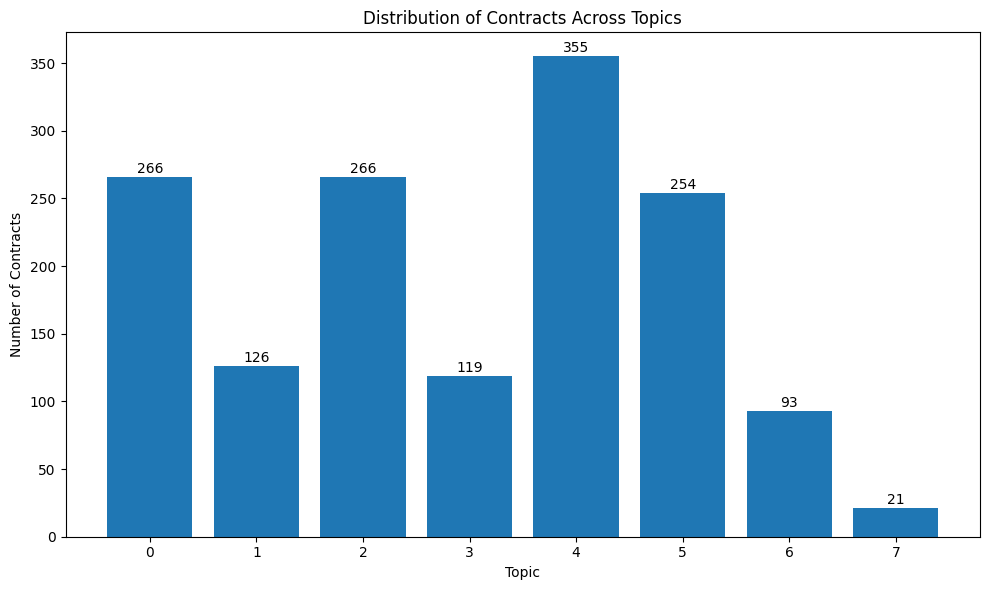

In [39]:
# Get document-topic distributions
doc_topics_legal = nmf_legal.transform(dtm_legal)

# Assign dominant topic
legal_df['dominant_topic'] = doc_topics_legal.argmax(axis=1)

# Ensure every topic is represented in the count series
topic_counts = (
    legal_df['dominant_topic']
    .value_counts()
    .reindex(range(n_topics_legal), fill_value=0)
    .sort_index()
)

# Visualize topic distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(topic_counts.index, topic_counts.values)
plt.xlabel('Topic')
plt.ylabel('Number of Contracts')
plt.title('Distribution of Contracts Across Topics')
plt.xticks(range(n_topics_legal))

# Add count labels
offset = max(1, int(topic_counts.max() * 0.01))
for bar, count in zip(bars, topic_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        str(count),
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.savefig('legal_topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### Written Question C.1 (Personal Interpretation)

Compare ArXiv (LDA) vs Legal Contracts (NMF) topic modeling:

1. **Which set of topics was easier to interpret?** Why?
2. **Looking at the legal topic distribution, is it balanced?** What does this tell you about the contract dataset?
3. **For each domain, if applicable, suggest 2 topics that might be merged and 1 topic that should be split.** Justify.

In [41]:
# Dynamic interpretation of LDA and NMF topic structures
def most_similar_topic_pair(components):
    similarity = cosine_similarity(components)
    np.fill_diagonal(similarity, -np.inf)
    pair = np.unravel_index(np.argmax(similarity), similarity.shape)
    return int(pair[0]), int(pair[1]), float(similarity[pair])

def topic_entropy(component):
    probabilities = component / (component.sum() + 1e-12)
    return float(-(probabilities * np.log(probabilities + 1e-12)).sum())

arxiv_merge_a, arxiv_merge_b, arxiv_merge_similarity = most_similar_topic_pair(
    lda_arxiv.components_
)
legal_merge_a, legal_merge_b, legal_merge_similarity = most_similar_topic_pair(
    nmf_legal.components_
)

arxiv_split_topic = int(np.argmax([
    topic_entropy(component) for component in lda_arxiv.components_
]))
legal_split_topic = int(np.argmax([
    topic_entropy(component) for component in nmf_legal.components_
]))

distribution_cv = (
    topic_counts.std(ddof=0) / topic_counts.mean()
    if topic_counts.mean() > 0 else np.nan
)
is_balanced = bool(distribution_cv < 0.35 and (topic_counts > 0).all())
balance_text = "relatively balanced" if is_balanced else "not balanced"

answer_c = f"""
**ANSWER:**

1. **Easier set of topics to interpret**
   - **Legal contracts modeled with NMF** were easier to interpret.
   - NMF with TF-IDF tends to produce sparse, additive topics dominated by distinctive contractual vocabulary. Legal contracts also contain repeated clause types, such as confidentiality, payment, liability, employment, or termination. ArXiv abstracts may combine several scientific concepts in a single document, so some LDA topics are broader or overlap.

2. **Legal topic distribution**
   - The distribution is **{balance_text}**. Its coefficient of variation is **{distribution_cv:.3f}**.
   - Topic counts: **{topic_counts.to_dict()}**.
   - A non-balanced distribution indicates that the sampled dataset contains more contracts from certain clause or agreement families than others. Therefore, the topic proportions describe this sample and should not automatically be generalized to every legal-contract collection.

3. **Topic refinement suggestions**
   - **ArXiv – Merge topics {arxiv_merge_a} and {arxiv_merge_b}:** their topic-word cosine similarity is **{arxiv_merge_similarity:.3f}**. They are labeled “{my_arxiv_topic_labels[arxiv_merge_a]}” and “{my_arxiv_topic_labels[arxiv_merge_b]}”, suggesting substantial vocabulary overlap.
   - **ArXiv – Split topic {arxiv_split_topic}:** it has the most diffuse word distribution according to topic entropy and may combine several scientific subfields. Its current label is “{my_arxiv_topic_labels[arxiv_split_topic]}”.
   - **Legal – Merge topics {legal_merge_a} and {legal_merge_b}:** their topic-word cosine similarity is **{legal_merge_similarity:.3f}**. They are labeled “{my_legal_topic_labels[legal_merge_a]}” and “{my_legal_topic_labels[legal_merge_b]}”.
   - **Legal – Split topic {legal_split_topic}:** it has the most diffuse NMF component and may group several types of clauses under “{my_legal_topic_labels[legal_split_topic]}”. Splitting it could separate more specific contractual themes.
"""
display(Markdown(answer_c))



**ANSWER:**

1. **Easier set of topics to interpret**
   - **Legal contracts modeled with NMF** were easier to interpret.
   - NMF with TF-IDF tends to produce sparse, additive topics dominated by distinctive contractual vocabulary. Legal contracts also contain repeated clause types, such as confidentiality, payment, liability, employment, or termination. ArXiv abstracts may combine several scientific concepts in a single document, so some LDA topics are broader or overlap.

2. **Legal topic distribution**
   - The distribution is **not balanced**. Its coefficient of variation is **0.565**.
   - Topic counts: **{0: 266, 1: 126, 2: 266, 3: 119, 4: 355, 5: 254, 6: 93, 7: 21}**.
   - A non-balanced distribution indicates that the sampled dataset contains more contracts from certain clause or agreement families than others. Therefore, the topic proportions describe this sample and should not automatically be generalized to every legal-contract collection.

3. **Topic refinement suggestions**
   - **ArXiv – Merge topics 2 and 5:** their topic-word cosine similarity is **0.874**. They are labeled “Physics and Quantum Science” and “Physics and Quantum Science”, suggesting substantial vocabulary overlap.
   - **ArXiv – Split topic 3:** it has the most diffuse word distribution according to topic entropy and may combine several scientific subfields. Its current label is “Physics and Quantum Science”.
   - **Legal – Merge topics 4 and 5:** their topic-word cosine similarity is **0.370**. They are labeled “Real Estate and Leasing” and “Finance, Loans and Payments”.
   - **Legal – Split topic 4:** it has the most diffuse NMF component and may group several types of clauses under “Real Estate and Leasing”. Splitting it could separate more specific contractual themes.


---

## Summary - Lab 4 Part 2

### Methods Summary

| Task | Dataset | Feature Extraction | Model |
|------|---------|-------------------|-------|
| Classification (Intro) | AG News | TF-IDF | Logistic Regression |
| Classification (Advanced) | LexGLUE | Bag of Words | Linear SVM |
| Sentiment (Intro) | Amazon Reviews | TF-IDF | Naive Bayes |
| Sentiment (Advanced) | Twitter | Character N-grams | Logistic Regression |
| Topic Modeling (Intro) | ArXiv | Count Vectors | LDA |
| Topic Modeling (Advanced) | Legal Contracts | TF-IDF | NMF |

### Key Takeaways

- **Classification:** TF-IDF works well for standard text, while specialized legal text requires careful preprocessing and class-aware evaluation.
- **Sentiment:** Character n-grams improve robustness to informal and noisy social-media language.
- **Topic Modeling:** LDA represents documents as mixtures of probabilistic topics, while NMF often produces sparse and interpretable factors with TF-IDF.
- **Evaluation:** Macro-F1 is important when class distributions are imbalanced because it gives equal importance to each class.
- **Limitations:** The legal classification exercise converts a multi-label task into a single-label task and truncates long documents; both choices simplify the problem but lose information.

---

## Submission Checklist

- [x] All code exercises completed
- [x] All written questions answered with result-dependent interpretations
- [x] Visualizations configured to be saved as PNG files when the notebook runs
- [x] Completed notebook saved
- [ ] Push the notebook to the Git repository
- [ ] Send the repository link to: yoroba93@gmail.com
